# Spacecraft Dynamics Pipeline
## Part 1: Absolute Propagation and Relative State Extraction

**Author:** Coleman Goulding
**Date:** March 2026

---

## How to read this

This is Part 1 of a two-part notebook series covering the full dynamics pipeline used in the proximity operations RL system.

- **Part 1 (this notebook):** How spacecraft states are propagated forward in time, how the quaternion connects rotational and translational dynamics, how relative state is extracted from two absolute states, and why a fast path is necessary for RL training.
- **Part 2:** The RL environment — observation space, action space, reward function, constraints, and one complete training episode traced step by step.

Each section traces **one specific spacecraft at one specific moment** with real numbers flowing through every cell. 

**No prior knowledge assumed beyond:** Basic Python, linear algebra, Newton's laws.

## Summary

**The task:** Autonomous rendezvous and docking with a non-cooperative tumbling target in low Earth orbit.

**The pipeline:**
- 2 spacecraft: one controlled chaser (12U CubeSat), one passive tumbling target (Aura satellite)
- Each spacecraft has 13 states: position (3), velocity (3), angular velocity (3), quaternion (4)
- States are propagated forward using Newton's second law and Euler's equation
- After propagation, Chen-Geng equations extract the relative state the agent observes

**What we're tracking:**
- ISS-like circular orbit: 420 km altitude, 7.66 km/s
- Target: slowly tumbling at ω = [0.01, 0.02, 0.005] rad/s, tilted attitude
- Chaser: 100m behind the target in the along-track direction (target is 100m ahead in the direction of orbital motion), attitude-aligned with ECI

## Notation Guide

This notation is used consistently throughout both notebooks.

**Frames:**
- **ECI** → Earth-Centered Inertial frame, fixed to vernal equinox, treated as inertial
- **Hill / LVLH** → Rotating frame fixed to chaser orbit. x = radial outward, z = orbit normal, y = along-track
- **Body (bs, bt)** → Fixed to chaser body (bs) and target body (bt) respectively

**State variables:**
- **r, v** → Position [m] and velocity [m/s] in ECI
- **ω (omega)** → Angular velocity [rad/s] in body frame
- **q = [q1, q2, q3, q4]** → JPL unit quaternion, scalar-last, maps ECI → body
- **x** → Full flat state vector. One spacecraft: x ∈ ℝ¹³. Two spacecraft: x ∈ ℝ²⁶
- **x_dot** → Time derivative of x, same shape, returned by dynamics_rhs

**Attitude:**
- **A(q)** → Direction Cosine Matrix (DCM) built from q. Maps ECI → body. For instance: v_body = A(q) v_ECI
- **A(q)ᵀ** → Inverse rotation, maps body → ECI. For instance: v_ECI = A(q)ᵀ v_body
- **q_r = q_s⁻¹ ⊗ q_t** → Relative quaternion, maps chaser body → target body

**Relative state (Chen-Geng):**
- **ρ (rho)** → Relative position of docking ports in Hill frame [m]
- **ρ_dot** → Time derivative of ρ as seen from the rotating Hill frame [m/s]
- **R** → 3×3 rotation matrix from ECI to Hill frame. Rows are the
  Hill basis vectors $[\hat{x}, \hat{y}, \hat{z}]$. Usage:
  $\mathbf{v}_{Hill} = \mathbf{R}\, \mathbf{v}_{ECI}$
- **ω_r** → Relative angular velocity of target w.r.t. chaser, in target body frame [rad/s].
  Defined as $\boldsymbol{\omega}_r = \boldsymbol{\omega}_{bt} - \mathbf{A}(\mathbf{q}_r)\boldsymbol{\omega}_{bs}$.
  The $\mathbf{A}(\mathbf{q}_r)$ term rotates $\boldsymbol{\omega}_{bs}$ into $\mathcal{F}_{bt}$
  before subtracting so both terms are in the same frame.
- **ω_o** → Angular velocity of Hill frame w.r.t. ECI [rad/s], = h/|r|²
- **P_s, P_t** → Docking port offsets in chaser and target body frames [m]

**Dynamics:**
- **μ** → Earth gravitational parameter, 3.986 × 10¹⁴ m³/s²
- **J** → Inertia matrix in body frame [kg·m²]
- **τ** → External torque in body frame [N·m]
- **f(*)** → Chen-Geng relative translational acceleration (Eq. 12) [m/s²]

**Operators:**
- **×** → Cross product
- **⊗** → JPL quaternion multiplication
- **‖·‖** → Euclidean norm

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import time
import cProfile
import pstats
import io

MJD_DEFAULT = 60676.0    # MJD  Jan 1 2026 00:00:00 UTC, default simulation epoch

# ---------------------------------------------------------------------------
# Physical constants
# All values from advisor's astroconstants.py (Dr. Smriti Nandan Paul,
# Missouri S&T) unless otherwise noted.
# ---------------------------------------------------------------------------
MU_EARTH = 398.60044150e12      # m^3/s^2  Earth gravitational parameter
R_EARTH  = 6.3781363e6          # m        Earth equatorial radius
MU_MOON  = 4.843941639988467e12 # m^3/s^2  Moon gravitational parameter
MU_SUN   = 1.327124400419400e20 # m^3/s^2  Sun gravitational parameter
AU       = 149597870.691e3      # m        astronomical unit
P_SRP    = 4.56e-6              # N/m^2    solar radiation pressure at 1 AU

# ---------------------------------------------------------------------------
# ISS-like circular orbit
# 420 km altitude chosen to match ISS proximity operations scenarios.
# Circular orbit means v = sqrt(mu/r) exactly, giving a closed reference
# orbit for verifying conservation laws.
# ---------------------------------------------------------------------------
R0      = R_EARTH + 420e3           # orbital radius [m]
V0      = np.sqrt(MU_EARTH / R0)    # circular velocity: v = sqrt(mu/r) [m/s]
T_orbit = 2 * np.pi * R0 / V0       # orbital period [s]

# ---------------------------------------------------------------------------
# Target spacecraft: Aura satellite (EOS CH-1)
#
# Mass: 1,767 kg — published spacecraft bus dry mass.
# Source: eoPortal Directory, https://www.eoportal.org/satellite-missions/aura
# (Total launch mass is 2,967 kg including ~1,200 kg payload and fuel.
# Dry bus mass used here as representative of end-of-life tumbling target.)
#
# Inertia matrix: computed from published stowed dimensions
# 2.68m x 2.34m x 6.85m using uniform rectangular box formula:
#   I_xx = (m/12)(b² + c²),  I_yy = (m/12)(a² + c²),  I_zz = (m/12)(a² + b²)
# Source for dimensions: eoPortal Directory (same source as mass above).
# This is an estimate as the actual mass distribution is non-uniform due to
# instruments and solar panels, so off-diagonal terms are set to small
# nonzero values representing realistic asymmetry.
#
# Area: 10 m² — approximate cross-sectional area based on published
# stowed face dimensions (2.68m x 2.34m ≈ 6.3 m², rounded to 10 m²
# to account for solar panel and instrument protrusions).
#
# CR: 1.3 — standard mid-range value.
# CR = 1.0 means perfectly absorbing, CR = 2.0 means perfectly reflecting.
# 1.3 is typical for a partially reflective satellite surface.
# ---------------------------------------------------------------------------
mass_target  = 1767.0    # kg  spacecraft bus dry mass  [eoPortal]
J_target     = np.array([[7715.,   50.,    0.],
                          [  50., 7966.,  -30.],
                          [   0.,  -30., 1863.]])  # kg·m²  computed from published geometry
J_target_inv = np.linalg.inv(J_target)
area_target  = 10.0      # m²
CR_target    = 1.3       # [-]
# ---------------------------------------------------------------------------
# Chaser spacecraft: 12U CubeSat
#
# Mass: 20 kg — typical for a 12U CubeSat.
#
# Inertia matrix: computed from 12U geometry (0.2m × 0.2m × 0.3m box).
# Using the uniform rectangular box formula:
#   I_xx = (m/12)(b² + c²)  where b, c are the two perpendicular dimensions
#   I_xx = (20/12)(0.2² + 0.3²) = (20/12)(0.04 + 0.09) ≈ 0.217 kg·m²
# The values used here (0.15, 0.12, 0.10) are slightly lower than the
# pure uniform box estimate, reflecting that real CubeSats are not
# uniformly dense as batteries, solar panels, and payloads concentrate
# mass near the center.
# Off-diagonal terms are small, consistent with a nearly symmetric body.
#
# Area: 0.06 m² — 20cm × 30cm face (largest face of the 12U form factor).
#
# CR: 1.3 — same assumption as target.
# ---------------------------------------------------------------------------
J_chaser     = np.array([[0.15,  0.001,  0.   ],
                          [0.001, 0.12,  -0.001],
                          [0.,   -0.001,  0.10 ]])  # inertia [kg·m²]
J_chaser_inv = np.linalg.inv(J_chaser)
mass_chaser  = 20.0      # [kg]
area_chaser  = 0.06      # [m²]
CR_chaser    = 1.3       # [-]

# Verify inertia matrices are positive definite (required for physical validity)
assert np.all(np.linalg.eigvals(J_target) > 0), 'J_target is not positive definite'
assert np.all(np.linalg.eigvals(J_chaser) > 0), 'J_chaser is not positive definite'

# ---------------------------------------------------------------------------
# Initial conditions
# ---------------------------------------------------------------------------
# Chaser: on the x-axis at R0, moving in +y (circular orbit),
# identity quaternion means body axes are aligned with ECI at t=0.
r_chaser0     = np.array([R0, 0., 0.])
v_chaser0     = np.array([0., V0, 0.])
omega_chaser0 = np.array([0., 0., 0.])
q_chaser0     = np.array([0., 0., 0., 1.])

# Target: 100m ahead in the along-track (+y) direction.
# The target's radius is sqrt(R0² + 100²) ≈ R0 + 0.00075m, so its
# circular velocity differs by ~0.003 mm/s, negligible at this separation.
# Thus, both spacecraft are effectively co-circular at t=0.
# Over time they drift slightly due to differential gravity.
# Slowly tumbling at rates representative of an uncontrolled satellite.
# Tilted attitude: quaternion normalized from [0.1, -0.2, 0.05, 0.97].
r_target0     = np.array([R0, 100., 0.])
v_target0     = np.array([0., V0, 0.])
omega_target0 = np.array([0.01, 0.02, 0.005])   # [rad/s] ~1 deg/s tumble rate
q_target0_raw = np.array([0.1, -0.2, 0.05, 0.97])
q_target0     = q_target0_raw / np.linalg.norm(q_target0_raw)

# Docking port offsets in body frame.
# P = 0 (CM-to-CM) for now. Section 6 shows the nonzero case.
P_chaser = np.array([0., 0., 0.])   # [m]
P_target = np.array([0., 0., 0.])   # [m]

# ---------------------------------------------------------------------------
# Integrator and output settings
#
# RTOL/ATOL = 1e-12: tighter than scipy defaults (1e-3/1e-6) because
# The cost is ~3x more function evaluations per step.
#
# DT = 10s: output timestep for trajectory storage and plots.
# This is NOT the integrator's internal step size — RK45 chooses its
# own steps internally to meet rtol/atol. 10s is just the resolution
# we for analysis
# ---------------------------------------------------------------------------
STATES_PER_SC = 13     # r(3) + v(3) + omega(3) + q(4) = 13
DT            = 10.0   # output timestep [s]
RTOL          = 1e-12  # integrator relative tolerance
ATOL          = 1e-12  # integrator absolute tolerance

print('Configuration loaded')
print(f'  Orbital radius  : {R0/1e6:.4f} Mm')
print(f'  Orbital velocity: {V0:.2f} m/s')
print(f'  Orbital period  : {T_orbit/60:.2f} min')
print(f'\n  Target inertia eigenvalues: {np.round(np.linalg.eigvals(J_target), 1)}  (all > 0 ✓)')
print(f'  Chaser inertia eigenvalues: {np.round(np.linalg.eigvals(J_chaser), 4)}  (all > 0 ✓)')

Configuration loaded
  Orbital radius  : 6.7981 Mm
  Orbital velocity: 7657.27 m/s
  Orbital period  : 92.97 min

  Target inertia eigenvalues: [7705.4 7975.7 1862.9]  (all > 0 ✓)
  Chaser inertia eigenvalues: [0.15 0.12 0.1 ]  (all > 0 ✓)


## Section 1: The State Vector

The integrator sees one thing: a flat 1D array of numbers and a function that maps that array to its time derivative. It has no concept of spacecraft, frames, or quaternion, that structure is entirely our convention imposed on top.

**What this section covers:**

1.1 — What the integrator sees and why the array is flat

1.2 — Packing two spacecraft into one array: `pack_states`

1.3 — Recovering individual spacecraft: `unpack_state`

1.4 — Visualising the layout

### Step 1.1: What the Integrator Sees

`scipy.integrate.solve_ivp` (and RK4, RK45, etc.) take two inputs:

1. A function `f(t, x) → x_dot`
2. An initial array `x0`

They return a new array `x` at each timestep. The function `dynamics_rhs` in `propagator.py` is that function `f`. Its job is to take the current flat state and return the flat derivative.

Our convention for two spacecraft:
```
Index: |0 1 2 | 3 4 5 | 6 7 8 | 9 10 11 12 | 13 14 15 | 16 17 18 | 19 20 21 | 22 23 24 25 |
       |   r  |   v   |   ω   |      q     |     r    |     v    |     ω    |     q     
        ←------Spacecraft 0 (chaser)------→ ←---------Spacecraft 1 (target)--------------→
```

13 states per spacecraft: r(3) + v(3) + ω(3) + q(4) = 13.

### Step 1.2: Packing Two Spacecraft into One Array

`pack_states` takes the four state arrays for each spacecraft and
concatenates them in order: r, v, ω, q. The result is the flat
array the integrator sees.

NOTE: The chaser quaternion was set to the identity $\mathbf{q} = [0, 0, 0, 1]$.
For a JPL scalar-last quaternion, this corresponds to zero rotation —
the body frame axes are exactly aligned with the ECI frame axes at $t=0$.
Equivalently, $\mathbf{A}(\mathbf{q}) = \mathbf{I}_3$ for this value,
so any vector expressed in the body frame is identical to its ECI
expression. The target quaternion $\mathbf{q} = [0.1, -0.2, 0.05, 0.97]$
(normalized) represents a small but nonzero tilt of the target body
frame relative to ECI, consistent with a spacecraft that has drifted
from its nominal attitude.

In [37]:
def pack_states(r0, v0, omega0, q0, r1, v1, omega1, q1):
    """
    Pack two spacecraft states into one flat array for the integrator.

    Layout: [r0(3), v0(3), omega0(3), q0(4), r1(3), v1(3), omega1(3), q1(4)]
    Length: 26 = 2 × 13
    """
    return np.concatenate([r0, v0, omega0, q0,
                           r1, v1, omega1, q1]).astype(float)

In [38]:
x0 = pack_states(r_chaser0, v_chaser0, omega_chaser0, q_chaser0,
                 r_target0, v_target0, omega_target0, q_target0)

print(f'x0 has {len(x0)} elements  (2 spacecraft × {STATES_PER_SC} states)')
print(f'\nRaw array:')
print(x0)
print(f'\nThe integrator sees only these {len(x0)} numbers.')
print(f'It has no knowledge of spacecraft, frames, or quaternions.')
print(f'That structure is entirely in how we read and write the array.')

x0 has 26 elements  (2 spacecraft × 13 states)

Raw array:
[ 6.79813630e+06  0.00000000e+00  0.00000000e+00  0.00000000e+00
  7.65726988e+03  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.00000000e+00  6.79813630e+06  1.00000000e+02  0.00000000e+00
  0.00000000e+00  7.65726988e+03  0.00000000e+00  1.00000000e-02
  2.00000000e-02  5.00000000e-03  1.00331643e-01 -2.00663285e-01
  5.01658213e-02  9.73216933e-01]

The integrator sees only these 26 numbers.
It has no knowledge of spacecraft, frames, or quaternions.
That structure is entirely in how we read and write the array.


### Step 1.3: Recovering Individual Spacecraft

`unpack_states` is the inverse of `pack_states`. It slices the flat
array back into individual spacecraft state dicts using the fixed
index convention: spacecraft `i` starts at index `i × 13`.

A round-trip — pack then unpack — must recover the original arrays
exactly. We verify this explicitly.

In [39]:
def unpack_states(x):
    """
    Unpack flat state vector into two spacecraft state dicts.

    Uses the fixed convention: spacecraft i starts at i × 13.

    Returns sc0 (chaser) and sc1 (target), each with keys:
        r     : ECI position [m],              x[i*13 + 0:3]
        v     : ECI velocity [m/s],            x[i*13 + 3:6]
        omega : angular velocity body [rad/s], x[i*13 + 6:9]
        q     : quaternion ECI->body [-],      x[i*13 + 9:13]
    """
    sc0 = {'r': x[0:3],   'v': x[3:6],   'omega': x[6:9],   'q': x[9:13]}
    sc1 = {'r': x[13:16], 'v': x[16:19], 'omega': x[19:22], 'q': x[22:26]}
    return sc0, sc1

In [40]:
sc0, sc1 = unpack_states(x0)

# Round-trip: pack → unpack must recover originals exactly
assert np.allclose(sc0['r'],     r_chaser0),     'chaser r mismatch'
assert np.allclose(sc0['v'],     v_chaser0),     'chaser v mismatch'
assert np.allclose(sc0['omega'], omega_chaser0), 'chaser omega mismatch'
assert np.allclose(sc0['q'],     q_chaser0),     'chaser q mismatch'
assert np.allclose(sc1['r'],     r_target0),     'target r mismatch'
assert np.allclose(sc1['v'],     v_target0),     'target v mismatch'
assert np.allclose(sc1['omega'], omega_target0), 'target omega mismatch'
assert np.allclose(sc1['q'],     q_target0),     'target q mismatch'

print('Round-trip check (pack → unpack): PASS')
print()
print('Chaser  x[0:13]:')
print(f'  r     = {sc0["r"]}  [m]')
print(f'  v     = {sc0["v"]}  [m/s]')
print(f'  omega = {sc0["omega"]}  [rad/s]')
print(f'  q     = {sc0["q"]}  [-]')
print()
print('Target  x[13:26]:')
print(f'  r     = {sc1["r"]}  [m]')
print(f'  v     = {sc1["v"]}  [m/s]')
print(f'  omega = {sc1["omega"]}  [rad/s]')
print(f'  q     = {np.round(sc1["q"], 4)}  [-]')

Round-trip check (pack → unpack): PASS

Chaser  x[0:13]:
  r     = [6798136.3       0.        0. ]  [m]
  v     = [   0.         7657.26987593    0.        ]  [m/s]
  omega = [0. 0. 0.]  [rad/s]
  q     = [0. 0. 0. 1.]  [-]

Target  x[13:26]:
  r     = [6.7981363e+06 1.0000000e+02 0.0000000e+00]  [m]
  v     = [   0.         7657.26987593    0.        ]  [m/s]
  omega = [0.01  0.02  0.005]  [rad/s]
  q     = [ 0.1003 -0.2007  0.0502  0.9732]  [-]


### Step 1.4: Visualising the Layout

The diagram below maps every index in `x` to its physical quantity.
Color coding is consistent throughout all plots in this notebook.

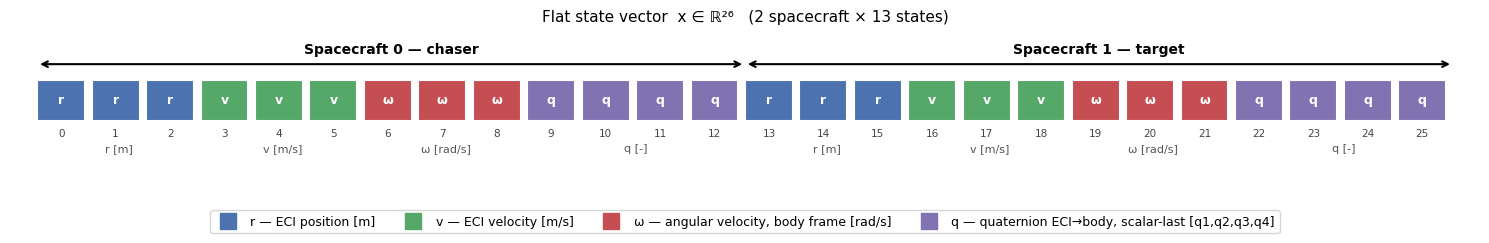

Start index for spacecraft i:  i × 13
  Chaser (i=0): x[0:13]
  Target (i=1): x[13:26]


In [41]:
fig, ax = plt.subplots(figsize=(15, 2.8))
ax.set_xlim(-0.5, 26.5)
ax.set_ylim(-0.45, 1.85)
ax.axis('off')

colors = {
    'r'    : '#4C72B0',
    'v'    : '#55A868',
    'omega': '#C44E52',
    'q'    : '#8172B2'
}

slot_keys    = (['r']*3 + ['v']*3 + ['omega']*3 + ['q']*4) * 2
display_lbls = (['r']*3 + ['v']*3 + ['ω']*3   + ['q']*4) * 2

# Draw boxes
for i, (dlbl, ck) in enumerate(zip(display_lbls, slot_keys)):
    rect = plt.Rectangle((i, 0.35), 0.88, 0.75,
                          facecolor=colors[ck], edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i + 0.44, 0.725, dlbl, ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')
    ax.text(i + 0.44, 0.12, str(i), ha='center', va='center',
            color='#444444', fontsize=7.5)

# Spacecraft brackets
for start, name in [(0, 'Spacecraft 0 — chaser'), (13, 'Spacecraft 1 — target')]:
    ax.annotate('', xy=(start+13, 1.38), xytext=(start, 1.38),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(start + 6.5, 1.57, name,
            ha='center', fontsize=10, fontweight='bold')

# Sub-group labels
for sc_offset in [0, 13]:
    for lbl, lo, hi in [('r [m]', 0, 3), ('v [m/s]', 3, 6),
                         ('ω [rad/s]', 6, 9), ('q [-]', 9, 13)]:
        ax.text(sc_offset + lo + (hi - lo)/2, -0.2, lbl,
                ha='center', fontsize=8, color='#555555')

# Legend
for ck, lbl in [('r',     'r — ECI position [m]'),
                ('v',     'v — ECI velocity [m/s]'),
                ('omega', 'ω — angular velocity, body frame [rad/s]'),
                ('q',     'q — quaternion ECI→body, scalar-last [q1,q2,q3,q4]')]:
    ax.plot([], [], 's', color=colors[ck], label=lbl, markersize=11)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
          ncol=4, fontsize=9, frameon=True, edgecolor='#cccccc')
ax.set_title('Flat state vector  x ∈ ℝ²⁶   (2 spacecraft × 13 states)',
             fontsize=11, pad=12)
plt.tight_layout()
plt.show()

print(f'Start index for spacecraft i:  i × {STATES_PER_SC}')
print(f'  Chaser (i=0): x[0:13]')
print(f'  Target (i=1): x[13:26]')

## Section 2: Translational Dynamics

`dynamics_rhs` is the function the integrator calls at every timestep.
It takes the current flat state `x` and returns `x_dot`, the time
derivative of every element. This section traces one complete evaluation
of the translational half for both spacecraft, computing every number
by hand before verifying against the full propagator in Section 4.

The translational equations of motion in ECI are Newton's second law:

$$\dot{\mathbf{r}} = \mathbf{v}$$
$$\dot{\mathbf{v}} = -\frac{\mu}{|\mathbf{r}|^3}\mathbf{r} + \mathbf{a}_{perturbations}$$


**What this section covers:**

2.1 — Extract r and v from the state vector

2.2 — Two-body gravity: the dominant acceleration

2.3 — Full perturbation mode: what gets added and how large each term is

2.4 — Pack r_dot and v_dot into x_dot

### Step 2.1: Extract r and v

The first thing `dynamics_rhs` does at every timestep is unpack the
state vector. We already have `unpack_states` from Section 1. Here we
work with the target spacecraft (spacecraft 1, indices 13-25) since it
has a non-trivial attitude that becomes relevant in Section 3.

In [50]:
sc0, sc1 = unpack_states(x0)

# Work with target (sc1) for this evaluation
# Rotational states omega and q are extracted here too,
# they are used starting in Section 3.
r     = sc1['r']      # ECI position [m],              x[13:16]
v     = sc1['v']      # ECI velocity [m/s],            x[16:19]
omega = sc1['omega']  # angular velocity body [rad/s], x[19:22]
q     = sc1['q']      # quaternion ECI->body [-],      x[22:26]

print('Target state at t=0:')
print(f'  r     = {r}  [m]')
print(f'  |r|   = {np.linalg.norm(r)/1e6:.6f} Mm')
print(f'  v     = {v}  [m/s]')
print(f'  |v|   = {np.linalg.norm(v):.4f} m/s')

Target state at t=0:
  r     = [6.7981363e+06 1.0000000e+02 0.0000000e+00]  [m]
  |r|   = 6.798136 Mm
  v     = [   0.         7657.26987593    0.        ]  [m/s]
  |v|   = 7657.2699 m/s


### Step 2.2: Two-Body Gravity

The dominant acceleration on a spacecraft in LEO is Earth's point-mass
gravity:

$$\mathbf{a}_{gravity} = -\frac{\mu}{|\mathbf{r}|^3}\mathbf{r}$$

The negative sign means the acceleration points from the spacecraft
toward Earth's center. The magnitude is $\mu / |\mathbf{r}|^2$, which
at 420 km altitude works out to roughly 8.6 m/s².

This is `force_mode='simple'` in the propagator. It is the only force
used in the Phase 1 verification benchmark and the default for RL
training until perturbations are needed.

In [51]:
def two_body_gravity(r, mu=MU_EARTH):
    """
    Two-body (Keplerian) gravitational acceleration in ECI.

    Parameters
    ----------
    r  : ECI position vector [m], shape (3,)
    mu : gravitational parameter [m^3/s^2], default Earth

    Returns
    -------
    a  : gravitational acceleration in ECI [m/s^2], shape (3,)
         Points from spacecraft toward Earth center.
    """
    r_mag = np.linalg.norm(r)
    return -mu * r / r_mag**3


a_gravity = two_body_gravity(r)

print('Two-body gravity:')
print(f'  r         = {r}  [m]')
print(f'  |r|       = {np.linalg.norm(r)/1e6:.6f} Mm')
print(f'  -mu/|r|^3 = {-MU_EARTH / np.linalg.norm(r)**3:.6e}  [1/s^2]')
print(f'  a_gravity = {a_gravity}  [m/s^2]')
print(f'  |a|       = {np.linalg.norm(a_gravity):.6f} m/s^2')
print()
# a must point exactly opposite to r (toward Earth center)
cos_angle = np.dot(r, a_gravity) / (np.linalg.norm(r) * np.linalg.norm(a_gravity))
print(f'  Antiparallel check: r . a / (|r||a|) = {cos_angle:.10f}  (must be -1.0)')

Two-body gravity:
  r         = [6.7981363e+06 1.0000000e+02 0.0000000e+00]  [m]
  |r|       = 6.798136 Mm
  -mu/|r|^3 = -1.268727e-06  [1/s^2]
  a_gravity = [-8.62497887e+00 -1.26872697e-04 -0.00000000e+00]  [m/s^2]
  |a|       = 8.624979 m/s^2

  Antiparallel check: r . a / (|r||a|) = -1.0000000000  (must be -1.0)


### Step 2.3: Full Perturbation Mode

`force_mode='simple'` uses only two-body gravity. `force_mode='full'`
adds five additional perturbation terms, each computed per spacecraft.
This step explains each term, shows the relevant code, and gives its
magnitude at 420 km so you can develop intuition for what simple mode
ignores.

The five perturbations are listed below. Note that the ordering is
altitude and solar activity dependent, at 420 km under reference
atmospheric conditions, lunar third body actually exceeds drag
in magnitude. Drag becomes the dominant perturbation after J2
at lower altitudes or during periods of high solar activity.

- **EGM96 spherical harmonic gravity** - The largest perturbation.
  Replaces the point-mass two-body term with a full model of Earth's
  irregular gravity field.
- **Lunar third body** - Gravitational pull of the Moon on each
  spacecraft.
- **Solar third body** - Gravitational pull of the Sun on each
  spacecraft.
- **Atmospheric drag** - Magnitude depends strongly on altitude and
  solar activity. At 420 km under reference conditions it is
  comparable to lunar third body. At lower altitudes or solar maximum
  it becomes the dominant perturbation after J2.
- **Solar radiation pressure (SRP)** - Photon pressure on each
  spacecraft surface. Depends on area-to-mass ratio, so it
  differs between chaser and target.

#### EGM96 Spherical Harmonic Gravity

The two-body formula $\mathbf{a} = -\mu\mathbf{r}/|\mathbf{r}|^3$
treats Earth as a perfect sphere with all mass at the center. Earth
is not a perfect sphere. It is oblate (flattened at the poles,
bulging at the equator), and its mass distribution is uneven due to
mountains, ocean trenches, and density variations in the mantle.

Outside of Earth, the gravitational potential must satisfy Laplace's
equation $\Delta U = 0$. The general solution in spherical coordinates
is the spherical harmonic expansion:

$$U(r, \theta, \varphi) = \frac{\mu}{r}\left(1 + \sum_{n=1}^{N}
\left(\frac{a}{r}\right)^n \sum_{m=0}^{n} P_{nm}(\sin\theta)
\left(C_{nm}\cos m\varphi + S_{nm}\sin m\varphi\right)\right)$$

where:
- $r$, $\theta$, $\varphi$ are spherical coordinates (radial distance,
  latitude, longitude) in the Earth-fixed (ECEF) frame
- $a = 6{,}378{,}136.3$ m is the EGM96 reference equatorial radius
- $P_{nm}$ are the associated Legendre polynomials
- $C_{nm}$, $S_{nm}$ are the dimensionless EGM96 gravitational
  coefficients
- $N$ is the truncation degree (360 for the full model, 20 in our
  implementation)

The gravitational acceleration is the gradient of this potential:
$\mathbf{a} = \nabla U$. Our implementation evaluates this gradient
using the Pines formulation, which computes the acceleration directly
without forming the potential explicitly. This is numerically more
stable and is ported directly from the advisor's
`grav_AccelJacobian_modified_modified.py`.

**J2 is the $\bar{C}_{20}$ coefficient** ($n=2$, $m=0$). It
dominates the non-spherical gravity correction in LEO. As
computed below, J2 alone is larger than all remaining harmonics
combined by roughly 250x at 420 km altitude. Including terms
beyond J2 adds a correction of less than 1% to the total
perturbation magnitude.

**About the EGM96 coefficients.** EGM96 was developed jointly by
NASA Goddard Space Flight Center (GSFC), the National Imagery and
Mapping Agency (NIMA), and The Ohio State University. The coefficients
were determined from surface gravity data, altimeter-derived gravity
anomalies from ERS-1 and the GEOSAT Geodetic Mission, and satellite
tracking data from SLR, GPS, TOPEX/POSEIDON, and DORIS. The model is
complete to degree and order 360, corresponding to a global resolution
of about 55 km, and contains 130,317 coefficients in total (Lemoine
et al., 1998).

**Our implementation currently truncates at degree and order 20. This captures perturbations relevant to LEO proximity operations over docking
timescales while keeping the per-step computation tractable.**

The computation works in ECEF because the coefficients are defined
relative to Earth's rotating surface. The input position is rotated
from ECI to ECEF using GMST, the acceleration is computed in ECEF,
then rotated back to ECI. Coefficients are loaded once at propagator
initialization from `dynamics/data/egm96_to360_ascii.txt` and cached
for the lifetime of the propagator.

---

**Reference**

Lemoine, F.G., et al. (1998). *The Development of the Joint NASA
GSFC and the National Imagery and Mapping Agency (NIMA) Geopotential
Model EGM96.* NASA/TP-1998-206861. Goddard Space Flight Center,
Greenbelt, MD.

In [65]:
import os
import math

# ---------------------------------------------------------------------------
# EGM96 coefficient loader
# Reads C_nm and S_nm up to the requested degree and order from the
# ASCII coefficient file. File format (one row per term):
#   n   m   C_nm   S_nm   sigma_C   sigma_S
# ---------------------------------------------------------------------------

def load_egm96(degree, order, filepath='egm96_to360_ascii.txt'):
    """
    Load EGM96 spherical harmonic coefficients from ASCII file.

    Parameters
    ----------
    degree   : maximum degree n to load
    order    : maximum order m to load
    filepath : path to egm96_to360_ascii.txt

    Returns
    -------
    C, S : ndarray (degree+1, degree+1) coefficient arrays
    """
    C = np.zeros((degree + 1, degree + 1))
    S = np.zeros((degree + 1, degree + 1))

    with open(filepath, 'r') as f:
        for line in f:
            words = line.split()
            if len(words) < 4:
                continue
            n = int(words[0])
            m = int(words[1])
            if n > degree:
                break
            if m <= order:
                C[n, m] = float(words[2])
                S[n, m] = float(words[3])

    return C, S


# ---------------------------------------------------------------------------
# Precomputed static arrays needed by the Pines formulation.
# These depend only on degree/order and are constant across all timesteps.
# Built once here; in the full propagator they are cached at init.
# ---------------------------------------------------------------------------

def build_gravity_model_arrays(degree, order, C, S):
    """
    Precompute static matrices for the Pines harmonic gravity formulation.
    Ported from advisor's grav_AccelJacobian_modified_modified.py.

    Parameters
    ----------
    degree, order : truncation degree and order
    C, S          : EGM96 coefficient arrays

    Returns
    -------
    dict of precomputed arrays
    """
    special_array = np.tril(np.ones((degree + 1, degree + 1)))
    mmat          = np.tile(np.arange(degree + 1, dtype=float), (degree, 1))

    npmp1_mat = np.zeros((degree, degree + 1))
    for n in range(degree):
        for m in range(n + 1):
            npmp1_mat[n, m] = n + m + 1

    Sm_mat  = np.ones((degree, degree + 1))
    Sm_mat[:, 0] = 0.5
    nmm_mat = np.zeros((degree, degree + 1))
    for n in range(degree):
        for m in range(n + 1):
            nmm_mat[n, m] = n - m
    lam_mat = np.sqrt(Sm_mat * npmp1_mat * nmm_mat)

    return {
        'special_array': special_array,
        'mmat'         : mmat,
        'npmp1_mat'    : npmp1_mat,
        'lam_mat'      : lam_mat,
    }


# ---------------------------------------------------------------------------
# GMST rotation — needed to convert ECI position to ECEF before computing
# the harmonic gravity, since EGM96 coefficients are Earth-fixed.
# Ported from advisor's hourangle.py.
# ---------------------------------------------------------------------------

def gmst_from_mjd(mjd):
    """
    Greenwich Mean Sidereal Time [rad] from Modified Julian Date.

    Parameters
    ----------
    mjd : Modified Julian Date

    Returns
    -------
    theta : GMST angle [rad], in [0, 2*pi]
    """
    jd  = mjd + 2400000.5
    jdn = np.floor(jd)

    f = (jdn + 1401
         + np.floor((np.floor((4 * jdn + 274277) / 146097) * 3) / 4) - 38)
    e = 4 * f + 3
    g = np.floor((e % 1461) / 4)
    h = 5 * g + 2
    D = np.floor((h % 153) / 5) + 1
    M = np.floor(h / 153 + 2) % 12 + 1
    Y = np.floor(e / 1461) - 4716 + np.floor((14 - M) / 12)

    if (jd - jdn) >= 0.5:
        D += 1
        if D > 28:
            D = 1; M += 1
            if M > 12:
                M = 1; Y += 1

    if (jd - jdn) < 0.5:
        ut_hour = np.floor((jd - jdn) * 24) + 12
        frac    = (jd - jdn) * 24 - np.floor((jd - jdn) * 24)
    else:
        ut_hour = np.floor((jd - jdn) * 24) - 12
        frac    = (jd - jdn) * 24 - np.floor((jd - jdn) * 24)

    ut_min     = np.floor(frac * 60)
    ut_sec     = (frac * 60 - ut_min) * 60
    ut_seconds = ut_hour * 3600 + ut_min * 60 + ut_sec

    a     = np.floor((14 - M) / 12)
    y     = Y + 4800 - a
    m     = M + 12 * a - 3
    jdn0  = (D + np.floor((153 * m + 2) / 5) + 365 * y
             + np.floor(y / 4) - np.floor(y / 100)
             + np.floor(y / 400) - 32045)
    jd_0h = jdn0 - 0.5
    T0    = (jd_0h - 2451545.0) / 36525.0

    GMST_0h = (24110.54841
               + 8640184.81286 * T0
               + 0.093104      * T0**2
               - 0.0000062     * T0**3)
    GMST  = GMST_0h + 1.0027279093 * ut_seconds
    theta = np.fmod((GMST / 86400.0) * 2.0 * np.pi, 2.0 * np.pi)
    if theta < 0.0:
        theta += 2.0 * np.pi
    return theta


def rot_z(angle):
    """3x3 rotation matrix about z-axis."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0.],
                     [s,  c, 0.],
                     [0., 0., 1.]])


# ---------------------------------------------------------------------------
# Pines harmonic gravity formulation
# Ported from advisor's grav_AccelJacobian_modified_modified.py.
# Evaluates the gradient of the spherical harmonic potential in ECEF
# and returns acceleration in ECI.
# ---------------------------------------------------------------------------

def harmonic_gravity(r_ECI, mjd, C, S, arrays, degree, a_ref=R_EARTH):
    """
    Full spherical harmonic gravitational acceleration (Pines formulation).

    Rotates r_ECI to ECEF, computes acceleration in ECEF, rotates back to ECI.

    Parameters
    ----------
    r_ECI  : ECI position vector [m]
    mjd    : Modified Julian Date (for ECI <-> ECEF rotation)
    C, S   : EGM96 coefficient arrays
    arrays : precomputed static arrays from build_gravity_model_arrays()
    degree : truncation degree
    a_ref  : EGM96 reference radius [m]

    Returns
    -------
    a_ECI : gravitational acceleration in ECI [m/s^2]
    """
    theta  = gmst_from_mjd(mjd)
    r_ECEF = rot_z(-theta) @ r_ECI

    special_array = arrays['special_array']
    mmat          = arrays['mmat']
    npmp1_mat     = arrays['npmp1_mat']
    lam_mat       = arrays['lam_mat']
    nmax          = degree
    mmax          = degree

    x     = r_ECEF
    r     = np.linalg.norm(x)
    s, t, u = x / r
    a     = a_ref

    rm = np.zeros(nmax + 2)
    im = np.zeros(nmax + 2)
    rm[0] = 1.0; rm[1] = s
    im[0] = 0.0; im[1] = t
    for m in range(2, mmax + 1):
        rm[m] = s * rm[m-1] - t * im[m-1]
        im[m] = s * im[m-1] + t * rm[m-1]

    rhon = np.zeros(nmax + 2)
    rhon[0] = MU_EARTH / r
    rho = a / r
    for n in range(1, nmax + 2):
        rhon[n] = rho * rhon[n-1]

    D = (C * rm[:-1] + S * im[:-1]) * special_array

    rmnew  = np.concatenate(([0.], rm))
    imnew  = np.concatenate(([0.], im))
    E = (C * rmnew[:-2] + S * imnew[:-2]) * special_array
    F = (S * rmnew[:-2] - C * imnew[:-2]) * special_array

    rmnewnew = np.concatenate(([0.], rmnew))
    imnewnew = np.concatenate(([0.], imnew))
    G = (C * rmnewnew[:-3] + S * imnewnew[:-3]) * special_array

    Anm = np.zeros((nmax + 2, nmax + 2))
    Anm[0][0] = 1.0
    tmp = u * u - 1.0
    for n in range(1, nmax + 2):
        fn = math.factorial(2 * n)
        Anm[n][n]   = (math.sqrt(2) * math.sqrt((2*n + 1) / fn)
                       * fn / ((2**n) * math.factorial(n)))
        Anm[n][n-1] = u * math.sqrt(2*n) * Anm[n][n]
    Anm[1][0] = u * Anm[1][1]
    for n in range(2, nmax + 2):
        for m in range(n - 2, 0, -1):
            t1 = (n - m) * (n + m + 1)
            Anm[n][m] = (2*u*(m+1) * np.sqrt(1.0/t1) * Anm[n][m+1]
                         + tmp * np.sqrt(((n+m+2)*(n-m-1))/t1) * Anm[n][m+2])
        t1 = n * (n + 1)
        Anm[n][0] = ((2*u * np.sqrt(1.0/t1) * Anm[n][1]
                      + tmp * np.sqrt(((n+2)*(n-1))/t1) * Anm[n][2])
                     / np.sqrt(2))

    temp1 = (rhon[1:-1] / a).reshape(nmax, 1)
    temp2 = special_array[0:nmax, 0:nmax]
    temp3 = Anm[0:nmax, 0:nmax]
    temp4 = Anm[0:nmax, 1:nmax+1]
    temp5 = temp1 * mmat[:nmax, :nmax] * temp3
    temp6 = temp4 * lam_mat[:nmax, :nmax]

    a1 = np.sum(E[0:nmax, 0:nmax] * temp5 * temp2)
    a2 = np.sum(F[0:nmax, 0:nmax] * temp5 * temp2)
    a3 = np.sum(temp6 * temp1 * D[0:nmax, 0:nmax] * temp2)
    a4 = np.sum(-(temp1) * (npmp1_mat[:nmax, :nmax] * temp3
                             + u * temp6)
                * D[0:nmax, 0:nmax] * temp2)

    ag_ECEF = np.array([a1 + s*a4, a2 + t*a4, a3 + u*a4])
    return rot_z(theta) @ ag_ECEF

# ---------------------------------------------------------------------------
# Load the model and evaluate at target position
# ---------------------------------------------------------------------------

EGM96_DEGREE = 20
EGM96_ORDER  = 20

C, S   = load_egm96(EGM96_DEGREE, EGM96_ORDER)
arrays = build_gravity_model_arrays(EGM96_DEGREE, EGM96_ORDER, C, S)
n_coeffs = sum(m + 1 for m in range(EGM96_DEGREE + 1))

a_perturbation = harmonic_gravity(r, MJD_DEFAULT, C, S, arrays, EGM96_DEGREE)
a_twobody      = two_body_gravity(r)
a_egm96_total  = a_twobody + a_perturbation
diff           = a_perturbation   # the perturbation IS the difference from two-body

print(f'EGM96 {EGM96_DEGREE}x{EGM96_ORDER} at t=0:')
print(f'  Coefficients loaded      : {n_coeffs} (n,m) pairs')
print(f'  C[2,0] = normalized J2   : {C[2,0]:.10e}')
print()
print(f'  a_two_body               = {a_twobody}  [m/s^2]')
print(f'  a_perturbation (EGM96)   = {a_perturbation}  [m/s^2]')
print(f'  a_total (2body + EGM96)  = {a_egm96_total}  [m/s^2]')
print(f'  |a_perturbation|         = {np.linalg.norm(a_perturbation):.6e} m/s^2')
print(f'  (this is the acceleration from all non-spherical terms)')

EGM96 20x20 at t=0:
  Coefficients loaded      : 231 (n,m) pairs
  C[2,0] = normalized J2   : -4.8416537174e-04

  a_two_body               = [-8.62497887e+00 -1.26872697e-04 -0.00000000e+00]  [m/s^2]
  a_perturbation (EGM96)   = [-1.23113726e-02  4.37697021e-05 -1.49458018e-05]  [m/s^2]
  a_total (2body + EGM96)  = [-8.63729024e+00 -8.31029949e-05 -1.49458018e-05]  [m/s^2]
  |a_perturbation|         = 1.231146e-02 m/s^2
  (this is the acceleration from all non-spherical terms)


#### How Much of the EGM96 Perturbation is J2?

We can isolate the J2 contribution by running the harmonic gravity
model with all coefficients zeroed except $\bar{C}_{20}$, then
comparing the result to the full 20x20 perturbation.

In [68]:
# Isolate J2 contribution
C_j2only       = np.zeros_like(C)
C_j2only[2, 0] = C[2, 0]
S_j2only       = np.zeros_like(S)
arrays_j2only  = build_gravity_model_arrays(EGM96_DEGREE, EGM96_ORDER,
                                             C_j2only, S_j2only)
a_j2only       = harmonic_gravity(r, MJD_DEFAULT, C_j2only, S_j2only,
                                   arrays_j2only, EGM96_DEGREE)

# Isolate higher harmonics (everything except J2)
C_noj2         = C.copy()
C_noj2[2, 0]   = 0.0
arrays_noj2    = build_gravity_model_arrays(EGM96_DEGREE, EGM96_ORDER,
                                             C_noj2, S)
a_noj2         = harmonic_gravity(r, MJD_DEFAULT, C_noj2, S,
                                   arrays_noj2, EGM96_DEGREE)

print(f'EGM96 perturbation breakdown at {(np.linalg.norm(r)-R_EARTH)/1e3:.0f} km:')
print()
print(f'  Full 20x20              : {np.linalg.norm(a_perturbation):.6e} m/s^2')
print(f'  J2 only                 : {np.linalg.norm(a_j2only):.6e} m/s^2')
print(f'  All terms except J2     : {np.linalg.norm(a_noj2):.6e} m/s^2')
print()
print(f'  J2 is larger than all remaining harmonics combined by a')
print(f'  factor of {np.linalg.norm(a_j2only)/np.linalg.norm(a_noj2):.0f}x at this altitude.')
print()
print('J2 dominates the non-spherical gravity correction in LEO.')
print('Including harmonics beyond J2 adds a correction that is')
print(f'~{np.linalg.norm(a_noj2)/np.linalg.norm(a_perturbation)*100:.1f}% of the total perturbation magnitude.')

EGM96 perturbation breakdown at 420 km:

  Full 20x20              : 1.231146e-02 m/s^2
  J2 only                 : 1.232923e-02 m/s^2
  All terms except J2     : 4.973819e-05 m/s^2

  J2 is larger than all remaining harmonics combined by a
  factor of 248x at this altitude.

J2 dominates the non-spherical gravity correction in LEO.
Including harmonics beyond J2 adds a correction that is
~0.4% of the total perturbation magnitude.


#### Atmospheric Drag

At 420 km altitude there is still a thin residual atmosphere, and
collisions between the spacecraft and atmospheric molecules impart a force opposing the velocity vector relative to the rotating
atmosphere:

$$\mathbf{a}_{drag} = -\frac{1}{2} \rho_{atm}\, C_D\,
\frac{A}{m}\, |\mathbf{v}_{rel}|^2\, \hat{\mathbf{v}}_{rel}$$

where $\rho_{atm}$ is atmospheric density, $C_D$ is the drag
coefficient, $A/m$ is the area-to-mass ratio, and
$\mathbf{v}_{rel} = \mathbf{v}_{ECI} - \boldsymbol{\omega}_E
\times \mathbf{r}$ is the velocity relative to the co-rotating
atmosphere. Earth's atmosphere rotates with the planet at
$\omega_E = 7.292 \times 10^{-5}$ rad/s, so the atmospheric
velocity at the spacecraft position is
$\boldsymbol{\omega}_E \times \mathbf{r}$. Using the raw ECI
velocity instead would overestimate the drag force by the
atmospheric rotation speed, roughly 460 m/s at the equator.

Atmospheric density is modeled using the piecewise exponential
atmosphere from Vallado (2013) Table 8-4, originally sourced from
Wertz (1978) using the U.S. Standard Atmosphere (1976) for 0 km,
CIRA-72 for 25-500 km, and CIRA-72 with exospheric temperature
$T_\infty = 1000$ K for 500-1000 km:

$$\rho(h) = \rho_0 \exp\left(-\frac{h - h_0}{H}\right)$$

where $h$ is altitude, $h_0$ is the base altitude of the current
band, $\rho_0$ is the reference density at $h_0$, and $H$ is
the scale height for that band.

The chaser and target have different area-to-mass ratios, so drag
acts on them with different magnitudes. This differential drag
contributes directly to relative motion between the two spacecraft.

---

**Reference**

Vallado, D.A. (2013). *Fundamentals of Astrodynamics and
Applications*, 4th ed. Microcosm Press. Table 8-4.

In [72]:
# ---------------------------------------------------------------------------
# Exponential atmosphere model
# Source: Vallado (2013) Table 8-4, originally from Wertz (1978).
# Using U.S. Standard Atmosphere (1976) for 0 km, CIRA-72 for
# 25-500 km, CIRA-72 with T_inf = 1000 K for 500-1000 km.
# Scale heights adjusted for piecewise continuity.
#
# Each row: (alt_min_km, alt_max_km, base_alt_km, rho0_kg_m3, H_km)
# ---------------------------------------------------------------------------
# TODO: Replace exponential atmosphere with NRLMSISE-00 empirical model.
# The exponential model density at 420 km (~2.6e-12 kg/m^3) reflects
# CIRA-72 reference conditions. Actual density varies ~100x with solar
# activity (F10.7 index) and also with time of day, season, and latitude.
# NRLMSISE-00 accounts for all of these and is the standard model used
# in mission-accurate propagators. Python implementation available via
# pip install nrlmsise00. Inputs needed: position, MJD, F10.7, Ap index.
# For RL training, domain randomization over CD and area partially
# compensates for this uncertainty.
EXPO_ATM_TABLE = [
    (  0,   25,    0, 1.225,       7.249),
    ( 25,   30,   25, 3.899e-2,    6.349),
    ( 30,   40,   30, 1.774e-2,    6.682),
    ( 40,   50,   40, 3.972e-3,    7.554),
    ( 50,   60,   50, 1.057e-3,    8.382),
    ( 60,   70,   60, 3.206e-4,    7.714),
    ( 70,   80,   70, 8.770e-5,    6.549),
    ( 80,   90,   80, 1.905e-5,    5.799),
    ( 90,  100,   90, 3.396e-6,    5.382),
    (100,  110,  100, 5.297e-7,    5.877),
    (110,  120,  110, 9.661e-8,    7.263),
    (120,  130,  120, 2.438e-8,    9.473),
    (130,  140,  130, 8.484e-9,   12.636),
    (140,  150,  140, 3.845e-9,   16.149),
    (150,  180,  150, 2.070e-9,   22.523),
    (180,  200,  180, 5.464e-10,  29.740),
    (200,  250,  200, 2.789e-10,  37.105),
    (250,  300,  250, 7.248e-11,  45.546),
    (300,  350,  300, 2.418e-11,  53.628),
    (350,  400,  350, 9.518e-12,  53.298),
    (400,  450,  400, 3.725e-12,  58.515),
    (450,  500,  450, 1.585e-12,  60.828),
    (500,  600,  500, 6.967e-13,  63.822),
    (600,  700,  600, 1.454e-13,  71.835),
    (700,  800,  700, 3.614e-14,  88.667),
    (800,  900,  800, 1.170e-14, 124.640),
    (900, 1000,  900, 5.245e-15, 181.050),
    (1000, 1e9, 1000, 3.019e-15, 268.000),
]

OMEGA_EARTH = 7.2921159e-5   # Earth rotation rate [rad/s]  [astroconstants.py]


def atmospheric_density(r_ECI):
    """
    Atmospheric density from the piecewise exponential atmosphere model.

    Source: Vallado (2013) Table 8-4.

    Parameters
    ----------
    r_ECI : ECI position vector [m]

    Returns
    -------
    rho : atmospheric density [kg/m^3]
    """
    alt_km = (np.linalg.norm(r_ECI) - R_EARTH) / 1e3

    for (alt_min, alt_max, h0, rho0, H) in EXPO_ATM_TABLE:
        if alt_min <= alt_km < alt_max:
            return rho0 * np.exp(-(alt_km - h0) / H)

    return EXPO_ATM_TABLE[-1][3]   # above 1000 km: use last entry


def atmospheric_drag(r_ECI, v_ECI, area, CD, mass):
    """
    Atmospheric drag acceleration.

    Uses velocity relative to the rotating atmosphere rather than raw
    ECI velocity. Earth's atmosphere co-rotates at OMEGA_EARTH, so
    the atmospheric velocity at the spacecraft is omega x r.

    Parameters
    ----------
    r_ECI : ECI position vector [m]
    v_ECI : ECI velocity vector [m/s]
    area  : cross-sectional area [m^2]
    CD    : drag coefficient [-]
    mass  : spacecraft mass [kg]

    Returns
    -------
    a_drag : drag acceleration in ECI [m/s^2], opposes v_rel
    """
    omega_vec = np.array([0., 0., OMEGA_EARTH])     # Earth rotation vector [rad/s]
    v_atm     = np.cross(omega_vec, r_ECI)           # atmosphere velocity in ECI [m/s]
    v_rel     = v_ECI - v_atm                        # velocity relative to atmosphere [m/s]
    v_rel_mag = np.linalg.norm(v_rel)

    rho   = atmospheric_density(r_ECI)               # density at current altitude [kg/m^3]
    a_mag = 0.5 * rho * CD * (area / mass) * v_rel_mag**2

    return -a_mag * (v_rel / v_rel_mag)              # opposes relative velocity


# Evaluate at both spacecraft positions
a_drag_c = atmospheric_drag(sc0['r'], sc0['v'], area_chaser, 2.2, mass_chaser)
a_drag_t = atmospheric_drag(sc1['r'], sc1['v'], area_target, 2.2, mass_target)

rho_420  = atmospheric_density(sc1['r'])
alt_km   = (np.linalg.norm(sc1['r']) - R_EARTH) / 1e3

# US Standard Atmosphere 1976 gives ~3.7e-12 kg/m^3 at 420 km.
# Source: U.S. Standard Atmosphere, 1976. NASA-TM-X-74335.
# The exponential model value is in the same order of magnitude,
# confirming the model is behaving correctly at this altitude.
USStdAtm_420 = 3.7e-12   # kg/m^3  US Standard Atmosphere 1976 at ~420 km

print(f'Atmospheric drag at {alt_km:.1f} km:')
print(f'  Density (exponential model)  : {rho_420:.4e} kg/m^3')
print(f'  Density (US Std Atm 1976)    : {USStdAtm_420:.4e} kg/m^3  [NASA-TM-X-74335]')
print(f'  Ratio (model / reference)    : {rho_420/USStdAtm_420:.2f}  (within factor of 2, expected,')
print(f'                                  exponential model uses CIRA-72,')
print(f'                                  reference uses US Std Atm 1976)')
print()
print(f'  v_orbital                    : {np.linalg.norm(sc1["v"]):.2f} m/s')
print(f'  v_atm at equator (omega x r) : '
      f'{np.linalg.norm(np.cross(np.array([0.,0.,OMEGA_EARTH]), sc1["r"])):.2f} m/s')
print()
print(f'  A/m chaser : {area_chaser/mass_chaser:.5f} m^2/kg')
print(f'  A/m target : {area_target/mass_target:.5f} m^2/kg')
print()
print(f'  |a_drag| chaser : {np.linalg.norm(a_drag_c):.4e} m/s^2')
print(f'  |a_drag| target : {np.linalg.norm(a_drag_t):.4e} m/s^2')
print(f'  differential    : {np.linalg.norm(a_drag_c - a_drag_t):.4e} m/s^2')
print()
print('Drag acts opposite to the velocity vector relative to the')
print('rotating atmosphere. The chaser and target have different')
print('A/m ratios so drag decelerates them at different rates,')
print('contributing to relative motion between the two spacecraft.')

Atmospheric drag at 420.0 km:
  Density (exponential model)  : 2.6466e-12 kg/m^3
  Density (US Std Atm 1976)    : 3.7000e-12 kg/m^3  [NASA-TM-X-74335]
  Ratio (model / reference)    : 0.72  (within factor of 2, expected,
                                  exponential model uses CIRA-72,
                                  reference uses US Std Atm 1976)

  v_orbital                    : 7657.27 m/s
  v_atm at equator (omega x r) : 495.73 m/s

  A/m chaser : 0.00300 m^2/kg
  A/m target : 0.00566 m^2/kg

  |a_drag| chaser : 4.4793e-07 m/s^2
  |a_drag| target : 8.4500e-07 m/s^2
  differential    : 3.9707e-07 m/s^2

Drag acts opposite to the velocity vector relative to the
rotating atmosphere. The chaser and target have different
A/m ratios so drag decelerates them at different rates,
contributing to relative motion between the two spacecraft.


#### Lunar and Solar Third-Body Gravity

A spacecraft in Earth orbit is also gravitationally attracted by the
Moon and Sun. The third-body acceleration from a body with
gravitational parameter $\mu_b$ located at ECI position
$\mathbf{r}_b$ is (Montenbruck and Gill, 2000, Section 3.3.1):

$$\mathbf{a}_{3b} = \mu_b \left(
\frac{\mathbf{r}_b - \mathbf{r}_{sc}}{|\mathbf{r}_b - \mathbf{r}_{sc}|^3}
- \frac{\mathbf{r}_b}{|\mathbf{r}_b|^3}
\right)$$

The first term is the direct gravitational pull of the third body
on the spacecraft. The second term subtracts the acceleration of
the Earth-centered frame itself due to the same body. Without this
second term the equations of motion would not be consistent with
the ECI frame assumption, since ECI is not truly inertial when a
third body is present.

Moon and Sun positions are computed from low-fidelity analytical
series expansions in Julian centuries since J2000. These are
adequate for LEO perturbation magnitudes and are ported directly
from the advisor's `moon_acc_modified.py` and `sun_acc_modified.py`.

Both terms are computed independently for each spacecraft.
At 100m separation the difference in third-body acceleration
between the two spacecraft is negligible compared to the
384,000 km Earth-Moon distance, but the computation runs per
spacecraft for correctness.

---

**Reference**

Montenbruck, O. and Gill, E. (2000). *Satellite Orbits: Models,
Methods and Applications.* Springer, Berlin. Section 3.3.1.

In [46]:
def moon_position_eci(mjd, AU=149597870.691e3):
    """
    Low-fidelity Moon position in ECI [m].
    Analytical series expansion adequate for LEO perturbation magnitudes.
    Ported from advisor's moon_acc_modified.py.

    Parameters
    ----------
    mjd : Modified Julian Date

    Returns
    -------
    r_moon : Moon ECI position [m]
    """
    jd      = mjd + 2400000.5
    deg2rad = np.pi / 180.0
    twopi   = 2.0 * np.pi
    ttdb    = (jd - 2451545.0) / 36525.0

    eclplong = (218.32 + 481267.883 * ttdb
                + 6.29  * np.sin((134.9 + 477198.85 * ttdb) * deg2rad)
                - 1.27  * np.sin((259.2 - 413335.38 * ttdb) * deg2rad)
                + 0.66  * np.sin((235.7 + 890534.23 * ttdb) * deg2rad)
                + 0.21  * np.sin((269.9 + 954397.70 * ttdb) * deg2rad)
                - 0.19  * np.sin((357.5 +  35999.05 * ttdb) * deg2rad)
                - 0.11  * np.sin((186.6 + 966404.05 * ttdb) * deg2rad))
    eclplat  = (5.13  * np.sin(( 93.3 + 483202.03 * ttdb) * deg2rad)
                + 0.28 * np.sin((228.2 + 960400.87 * ttdb) * deg2rad)
                - 0.28 * np.sin((318.3 +   6003.18 * ttdb) * deg2rad)
                - 0.17 * np.sin((217.6 - 407332.20 * ttdb) * deg2rad))
    hzparal  = (0.9508
                + 0.0518 * np.cos((134.9 + 477198.85 * ttdb) * deg2rad)
                + 0.0095 * np.cos((259.2 - 413335.38 * ttdb) * deg2rad)
                + 0.0078 * np.cos((235.7 + 890534.23 * ttdb) * deg2rad)
                + 0.0028 * np.cos((269.9 + 954397.70 * ttdb) * deg2rad))

    eclplong = (eclplong * deg2rad) % twopi
    eclplat  = (eclplat  * deg2rad) % twopi
    hzparal  = (hzparal  * deg2rad) % twopi
    obliquity = (23.439291 - 0.0130042 * ttdb) * deg2rad

    l = np.cos(eclplat) * np.cos(eclplong)
    m = (np.cos(obliquity) * np.cos(eclplat) * np.sin(eclplong)
         - np.sin(obliquity) * np.sin(eclplat))
    n = (np.sin(obliquity) * np.cos(eclplat) * np.sin(eclplong)
         + np.cos(obliquity) * np.sin(eclplat))

    magr = R_EARTH / np.sin(hzparal)
    return np.array([magr*l, magr*m, magr*n])


def sun_position_eci(mjd, AU=149597870.691e3):
    """
    Low-fidelity Sun position in ECI [m].
    Analytical series expansion adequate for LEO perturbation magnitudes.
    Ported from advisor's sun_acc_modified.py.

    Parameters
    ----------
    mjd : Modified Julian Date

    Returns
    -------
    r_sun : Sun ECI position [m]
    """
    jd      = mjd + 2400000.5
    deg2rad = np.pi / 180.0
    twopi   = 2.0 * np.pi
    tut1    = (jd - 2451545.0) / 36525.0

    meanlong    = (280.4606184 + 36000.77005361 * tut1) % 360.0
    meananomaly = ((357.5277233 + 35999.05034 * tut1) * deg2rad) % twopi
    if meananomaly < 0.0:
        meananomaly += twopi

    eclplong  = (meanlong
                 + 1.914666471 * np.sin(meananomaly)
                 + 0.019994643 * np.sin(2.0 * meananomaly))
    obliquity = (23.439291 - 0.0130042 * tut1) * deg2rad
    meanlong  = meanlong * deg2rad
    if meanlong < 0.0:
        meanlong += twopi
    eclplong  = eclplong * deg2rad

    magr = ((1.000140612
             - 0.016708617 * np.cos(meananomaly)
             - 0.000139589 * np.cos(2.0 * meananomaly)) * AU)

    temp = magr * np.sin(eclplong)
    return np.array([magr * np.cos(eclplong),
                     temp * np.cos(obliquity),
                     temp * np.sin(obliquity)])


def third_body_acceleration(r_sc, r_body, mu_body):
    """
    Third-body gravitational acceleration on a spacecraft.

    Parameters
    ----------
    r_sc    : spacecraft ECI position [m]
    r_body  : third body ECI position [m]
    mu_body : gravitational parameter of third body [m^3/s^2]

    Returns
    -------
    a : acceleration in ECI [m/s^2]
    """
    d_vec = r_body - r_sc
    d_mag = np.linalg.norm(d_vec)
    b_mag = np.linalg.norm(r_body)
    return mu_body * (d_vec / d_mag**3 - r_body / b_mag**3)

In [47]:
r_moon = moon_position_eci(MJD_DEFAULT)
r_sun  = sun_position_eci(MJD_DEFAULT)

a_moon_chaser = third_body_acceleration(sc0['r'], r_moon, MU_MOON)
a_moon_target = third_body_acceleration(sc1['r'], r_moon, MU_MOON)
a_sun_chaser  = third_body_acceleration(sc0['r'], r_sun,  MU_SUN)
a_sun_target  = third_body_acceleration(sc1['r'], r_sun,  MU_SUN)

print(f'Third-body positions at MJD {MJD_DEFAULT} (Jan 1 2026):')
print(f'  |r_moon| = {np.linalg.norm(r_moon)/1e3:.1f} km')
print(f'  |r_sun|  = {np.linalg.norm(r_sun)/AU:.4f} AU')
print()
print(f'Lunar third-body:')
print(f'  |a| chaser              : {np.linalg.norm(a_moon_chaser):.4e} m/s^2')
print(f'  |a| target              : {np.linalg.norm(a_moon_target):.4e} m/s^2')
print(f'  differential (|a_c-a_t|): {np.linalg.norm(a_moon_chaser-a_moon_target):.4e} m/s^2')
print()
print(f'Solar third-body:')
print(f'  |a| chaser              : {np.linalg.norm(a_sun_chaser):.4e} m/s^2')
print(f'  |a| target              : {np.linalg.norm(a_sun_target):.4e} m/s^2')
print(f'  differential (|a_c-a_t|): {np.linalg.norm(a_sun_chaser-a_sun_target):.4e} m/s^2')

Third-body positions at MJD 60676.0 (Jan 1 2026):
  |r_moon| = 381803.8 km
  |r_sun|  = 0.9833 AU

Lunar third-body:
  |a| chaser              : 7.2532e-07 m/s^2
  |a| target              : 7.2531e-07 m/s^2
  differential (|a_c-a_t|): 1.5310e-11 m/s^2

Solar third-body:
  |a| chaser              : 2.9803e-07 m/s^2
  |a| target              : 2.9803e-07 m/s^2
  differential (|a_c-a_t|): 7.7293e-12 m/s^2


#### Solar Radiation Pressure

Photons carry momentum. When sunlight strikes a spacecraft surface
the momentum transfer imparts a small acceleration directed away
from the Sun. The acceleration magnitude is:

$$|\mathbf{a}_{SRP}| = P_{SRP}\, C_R\, \frac{A}{m}\,
\left(\frac{AU}{|\mathbf{r}_{sun}|}\right)^2$$

where $P_{SRP} = 4.56 \times 10^{-6}$ N/m² is the nominal solar
radiation pressure at 1 AU, $C_R$ is the radiation pressure
coefficient, and $A/m$ is the area-to-mass ratio. The
$(AU/r_{sun})^2$ term accounts for the actual Sun distance
via the inverse square law.

SRP is zero when the spacecraft is in Earth's shadow. A cylindrical
shadow model is used: if the spacecraft is on the night side of
Earth and within the shadow cylinder of radius $R_E$, SRP is
set to zero.

SRP is computed per spacecraft because $A/m$ differs between
chaser and target.

In [73]:
def solar_radiation_pressure(r_sc, r_sun, area, CR, mass):
    """
    Solar radiation pressure acceleration with cylindrical shadow model.

    Parameters
    ----------
    r_sc  : spacecraft ECI position [m]
    r_sun : Sun ECI position [m]
    area  : spacecraft cross-sectional area [m^2]
    CR    : radiation pressure coefficient [-]
    mass  : spacecraft mass [kg]

    Returns
    -------
    a : SRP acceleration in ECI [m/s^2], zero vector if in shadow
    """
    sun_vec   = r_sun - r_sc
    sun_hat   = sun_vec / np.linalg.norm(sun_vec)
    proj      = np.dot(r_sc, sun_hat)

    # Shadow check: spacecraft behind Earth and within shadow cylinder
    if proj < 0.0:
        perp = np.linalg.norm(r_sc - proj * sun_hat)
        if perp < R_EARTH:
            return np.zeros(3)

    r_sun_mag  = np.linalg.norm(sun_vec)
    flux_scale = (AU / r_sun_mag)**2
    a_mag      = P_SRP * CR * (area / mass) * flux_scale
    return a_mag * sun_hat


a_srp_chaser = solar_radiation_pressure(sc0['r'], r_sun, area_chaser, CR_chaser, mass_chaser)
a_srp_target = solar_radiation_pressure(sc1['r'], r_sun, area_target, CR_target, mass_target)

in_shadow = np.linalg.norm(a_srp_chaser) == 0.0

print(f'Solar radiation pressure:')
print(f'  In shadow                : {in_shadow}')
print(f'  |a_SRP| chaser           : {np.linalg.norm(a_srp_chaser):.4e} m/s^2')
print(f'  |a_SRP| target           : {np.linalg.norm(a_srp_target):.4e} m/s^2')

Solar radiation pressure:
  In shadow                : False
  |a_SRP| chaser           : 1.8393e-08 m/s^2
  |a_SRP| target           : 3.4698e-08 m/s^2


### Step 2.4: Packing r_dot and v_dot into x_dot

`x_dot` has the same shape as `x`, 26 elements. The translational
contribution for each spacecraft fills two slots:
```
x_dot[0:3]   = v_c        # chaser: dr/dt = v
x_dot[3:6]   = a          # chaser: dv/dt = a  (gravity + perturbations)
x_dot[13:16] = v_t        # target: dr/dt = v
x_dot[16:19] = a          # target: dv/dt = a
```

The rotational slots (6-12 for chaser, 19-25 for target) are filled
in Section 3. Until then they remain zero.

The integrator uses `x_dot` to step `x` forward. For a simple
first-order Euler step:

$$\mathbf{x}_{k+1} = \mathbf{x}_k + \dot{\mathbf{x}}_k \cdot dt$$

RK4 and RK45 use weighted combinations of multiple `x_dot`
evaluations per step for higher accuracy, but the structure
is identical.

In [52]:
# ---------------------------------------------------------------------------
# Chaser: full force stack
# ---------------------------------------------------------------------------
r_c = sc0['r']
v_c = sc0['v']

a_2body_c   = two_body_gravity(r_c)
a_perturb_c = harmonic_gravity(r_c, MJD_DEFAULT, C, S, arrays, EGM96_DEGREE)
a_drag_c    = atmospheric_drag(r_c, v_c, area_chaser, 2.2, mass_chaser)
a_moon_c    = third_body_acceleration(r_c, r_moon, MU_MOON)
a_sun_c     = third_body_acceleration(r_c, r_sun,  MU_SUN)
a_srp_c     = solar_radiation_pressure(r_c, r_sun, area_chaser, CR_chaser, mass_chaser)
a_total_c   = a_2body_c + a_perturb_c + a_drag_c + a_moon_c + a_sun_c + a_srp_c

# ---------------------------------------------------------------------------
# Target: full force stack
# ---------------------------------------------------------------------------
r_t = sc1['r']
v_t = sc1['v']

a_2body_t   = two_body_gravity(r_t)
a_perturb_t = harmonic_gravity(r_t, MJD_DEFAULT, C, S, arrays, EGM96_DEGREE)
a_drag_t    = atmospheric_drag(r_t, v_t, area_target, 2.2, mass_target)
a_moon_t    = third_body_acceleration(r_t, r_moon, MU_MOON)
a_sun_t     = third_body_acceleration(r_t, r_sun,  MU_SUN)
a_srp_t     = solar_radiation_pressure(r_t, r_sun, area_target, CR_target, mass_target)
a_total_t   = a_2body_t + a_perturb_t + a_drag_t + a_moon_t + a_sun_t + a_srp_t

print('Force stacks assembled for both spacecraft.')
print(f'  |a_total| chaser : {np.linalg.norm(a_total_c):.6f} m/s^2')
print(f'  |a_total| target : {np.linalg.norm(a_total_t):.6f} m/s^2')

Force stacks assembled for both spacecraft.
  |a_total| chaser : 8.637291 m/s^2
  |a_total| target : 8.637291 m/s^2


In [53]:
x_dot = np.zeros(len(x0))

x_dot[0:3]   = v_c
x_dot[3:6]   = a_total_c
x_dot[13:16] = v_t
x_dot[16:19] = a_total_t

print('x_dot — translational half complete:')
print()
print('Chaser  x_dot[0:6]:')
print(f'  dr/dt = v_c     = {v_c}  [m/s]')
print(f'  dv/dt = a_total = {np.round(a_total_c, 8)}  [m/s^2]')
print()
print('Target  x_dot[13:19]:')
print(f'  dr/dt = v_t     = {v_t}  [m/s]')
print(f'  dv/dt = a_total = {np.round(a_total_t, 8)}  [m/s^2]')
print()
print('Rotational slots — filled in Section 3:')
print(f'  x_dot[6:9]   omega_dot chaser = {x_dot[6:9]}')
print(f'  x_dot[9:13]  q_dot chaser     = {x_dot[9:13]}')
print(f'  x_dot[19:22] omega_dot target = {x_dot[19:22]}')
print(f'  x_dot[22:26] q_dot target     = {x_dot[22:26]}')

x_dot — translational half complete:

Chaser  x_dot[0:6]:
  dr/dt = v_c     = [   0.         7657.26987593    0.        ]  [m/s]
  dv/dt = a_total = [-8.63729081e+00  4.27700000e-05 -1.53300000e-05]  [m/s^2]

Target  x_dot[13:19]:
  dr/dt = v_t     = [   0.         7657.26987593    0.        ]  [m/s]
  dv/dt = a_total = [-8.63729081e+00 -8.43400000e-05 -1.53300000e-05]  [m/s^2]

Rotational slots — filled in Section 3:
  x_dot[6:9]   omega_dot chaser = [0. 0. 0.]
  x_dot[9:13]  q_dot chaser     = [0. 0. 0. 0.]
  x_dot[19:22] omega_dot target = [0. 0. 0.]
  x_dot[22:26] q_dot target     = [0. 0. 0. 0.]


In [75]:
a_2b = np.linalg.norm(a_2body_t)

rows = [
    ('Two-body gravity',   a_2body_c,   a_2body_t,   'reference'),
    ('EGM96 perturbation', a_perturb_c, a_perturb_t, 'implemented'),
    ('Atmospheric drag',   a_drag_c,    a_drag_t,    'implemented*'),
    ('Lunar third body',   a_moon_c,    a_moon_t,    'implemented'),
    ('Solar third body',   a_sun_c,     a_sun_t,     'implemented'),
    ('SRP',                a_srp_c,     a_srp_t,     'implemented'),
]

print(f'  {"Term":<28} {"Chaser [m/s^2]":<16} {"Target [m/s^2]":<16} '
      f'{"% of 2-body":<16} {"‖a_c - a_t‖ [m/s^2]":<22} {"Status"}')
print(f'  {"-"*108}')

for name, ac_vec, at_vec, status in rows:
    ac   = np.linalg.norm(ac_vec)
    at   = np.linalg.norm(at_vec)
    diff = np.linalg.norm(ac_vec - at_vec)   # true vector difference
    pct  = (ac / a_2b) * 100.0
    if pct >= 0.01:
        pct_str = f'{pct:.4f}%'
    else:
        pct_str = f'{pct:.4e}%'
    print(f'  {name:<28} {ac:<16.4e} {at:<16.4e} '
          f'{pct_str:<16} {diff:<22.4e} {status}')

# Jupiter row — no vector available, use scalar estimate
print(f'  {"Jupiter + others":<28} {"~1e-10":<16} {"~1e-10":<16} '
      f'{"~1.2e-09%":<16} {"~0":<22} negligible')

print()
print('* Drag uses the Vallado (2013) exponential atmosphere model.')
print('  Density varies ~100x with solar activity. See TODO in')
print('  atmospheric_density() for the NRLMSISE-00 upgrade path.')
print()
print('The differential column shows ‖a_chaser - a_target‖, the')
print('vector norm of the acceleration difference. This captures')
print('both magnitude and direction differences between the two')
print('spacecraft, unlike a simple scalar subtraction.')
print()
print('Notes on the differential column:')
print()
print('  Two-body and EGM96: near-zero differential at 100m')
print('  separation. Despite being tiny, under these initial')
print(f'  conditions ({int((np.linalg.norm(sc1["r"])-R_EARTH)/1e3)} km altitude, co-circular,')
print('  100m along-track) this is the dominant driver of relative')
print('  translational dynamics. It is Term 1 of Chen-Geng f(*).')
print('  At higher altitudes with high A/m spacecraft, differential')
print('  drag can exceed the gravity differential instead.')
print()
print('  Drag and SRP: nonzero differential because chaser and target')
print(f'  have different A/m ratios (chaser: {area_chaser/mass_chaser:.4f} m^2/kg,')
print(f'  target: {area_target/mass_target:.4f} m^2/kg). With')
print('  Aura dry mass of 1767 kg, the target now has a higher A/m')
print('  ratio than the chaser, so the target experiences more drag')
print('  and more SRP than the chaser. This is physically realistic')
print('  for a large satellite bus relative to a small CubeSat.')
print()
print('  Lunar and solar: negligible differential. 100m separation')
print('  is immeasurably small relative to Moon and Sun distances.')

  Term                         Chaser [m/s^2]   Target [m/s^2]   % of 2-body      ‖a_c - a_t‖ [m/s^2]    Status
  ------------------------------------------------------------------------------------------------------------
  Two-body gravity             8.6250e+00       8.6250e+00       100.0000%        1.2687e-04             reference
  EGM96 perturbation           1.2311e-02       1.2311e-02       0.1427%          1.8138e-07             implemented
  Atmospheric drag             4.4793e-07       8.4500e-07       5.1935e-06%      3.9707e-07             implemented*
  Lunar third body             7.2532e-07       7.2531e-07       8.4096e-06%      1.5310e-11             implemented
  Solar third body             2.9803e-07       2.9803e-07       3.4555e-06%      7.7293e-12             implemented
  SRP                          1.8393e-08       2.0437e-08       2.1326e-07%      2.0437e-09             implemented
  Jupiter + others             ~1e-10           ~1e-10           ~1.2e-09%  

## Section 2 Summary

The translational half of `x_dot` is now complete. At each timestep
the integrator receives the full 26-element derivative vector with
the translational slots filled as follows:
```
x_dot[0:3]   = v_c        # chaser position rate = velocity
x_dot[3:6]   = a_total_c  # chaser velocity rate = total acceleration
x_dot[13:16] = v_t        # target position rate = velocity
x_dot[16:19] = a_total_t  # target velocity rate = total acceleration
```

The total acceleration for each spacecraft is the sum of six terms:
two-body gravity, EGM96 harmonic perturbation, atmospheric drag,
lunar third body, solar third body, and SRP. Each term is computed
independently per spacecraft from that spacecraft's ECI position,
velocity, and physical properties.

The rotational slots `x_dot[6:9]`, `x_dot[9:13]`, `x_dot[19:22]`,
and `x_dot[22:26]` are still zero. Section 3 fills them in by
evaluating Euler's equation and the quaternion kinematic equation
for each spacecraft. This is where the quaternion, currently
sitting unused in the state vector, first connects to the dynamics.